In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import Ball, Stick, Zeppelin, Dti, BallStick, Ball2Stick, Sphere, Cylinder, SandiB, SandiW
from dmri.simulators.acquisition_scheme import acquisition_scheme
from dmri.simulators.local_signal_models.distributional_models import WatsonStick, WatsonZeppelin,BinghamStick, BinghamZeppelin, NoddiW, NoddiB


In [3]:
bvals = jnp.linspace(0, 3000, 100)
bvecs = np.random.randn(100, 3)
bvecs = bvecs / np.linalg.norm(bvecs, axis=1)[:, None]

acq = acquisition_scheme(bvals, bvecs)


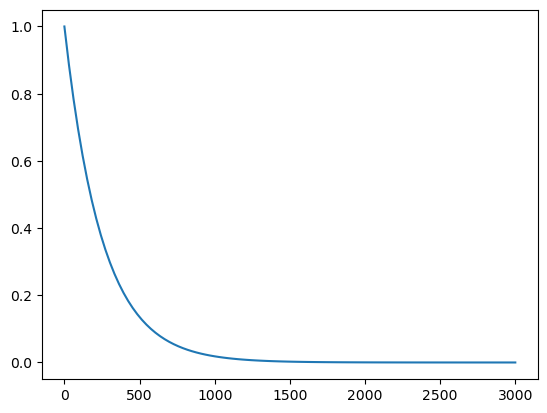

In [4]:
theta = np.random.randn(Ball.theta_dim)
ball = Ball.from_theta(theta)


signal = ball.signal(acq)

plt.plot(bvals, signal)

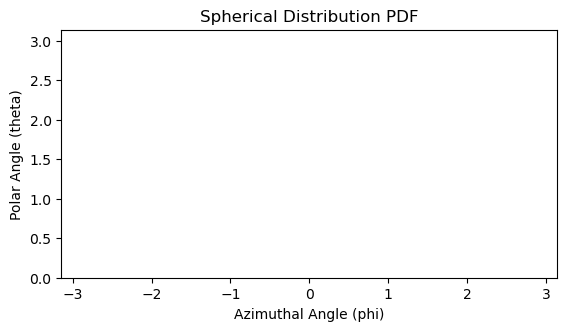

In [5]:

%matplotlib inline
ball.to_fod().viz()

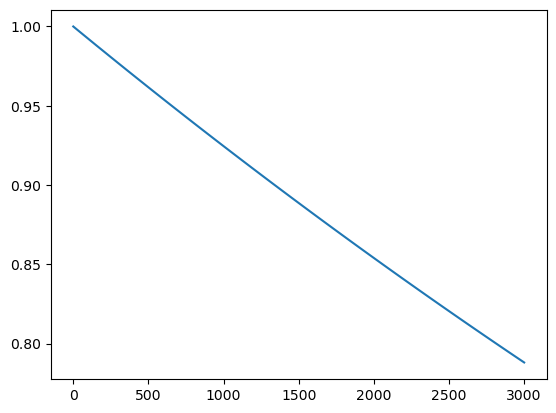

In [6]:
theta = np.random.randn(Sphere.theta_dim)
ball = Sphere.from_theta(theta)


signal = ball.signal(acq)

plt.plot(bvals, signal)

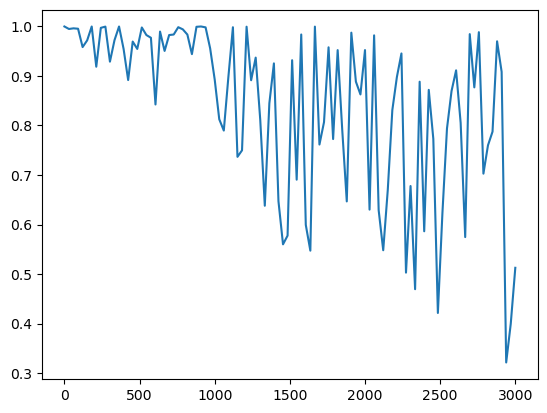

In [9]:
theta = np.random.randn(Stick.theta_dim)
stick = Stick.from_theta(theta)


signal = stick.signal(acq)

plt.plot(bvals, signal)

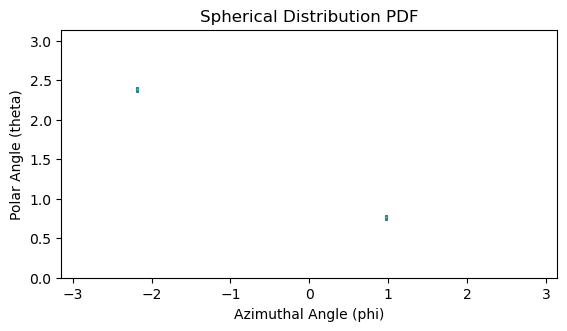

In [23]:
%matplotlib inline
theta = np.random.randn(Stick.theta_dim)
stick = Stick.from_theta(theta)
stick.to_fod().viz(plot_type='polar')

In [50]:
def stick_mu_samples(thetas):
    stick = Stick.from_theta(thetas)
    mu = stick.mu
    # Convert to cartesian
    mu = jnp.array([jnp.sin(mu[0]) * jnp.cos(mu[1]), jnp.sin(mu[0]) * jnp.sin(mu[1]), jnp.cos(mu[0])])
    return mu

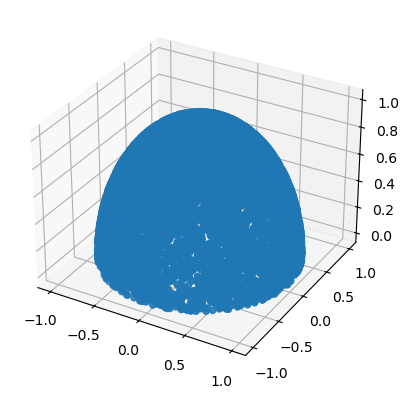

In [61]:
pos = jax.vmap(stick_mu_samples)(np.random.randn(10000, Stick.theta_dim))
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2])

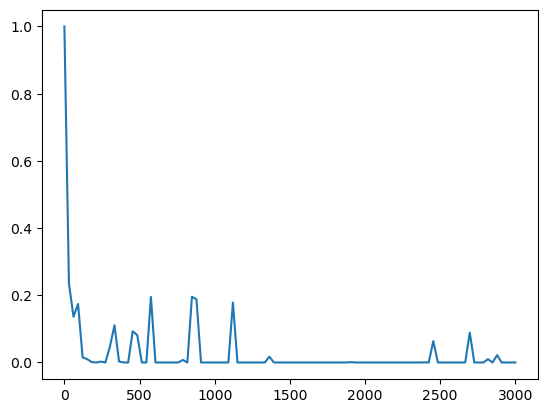

In [24]:
theta = np.random.randn(Cylinder.theta_dim)
stick = Cylinder.from_theta(theta)


signal = stick.signal(acq)

plt.plot(bvals, signal)

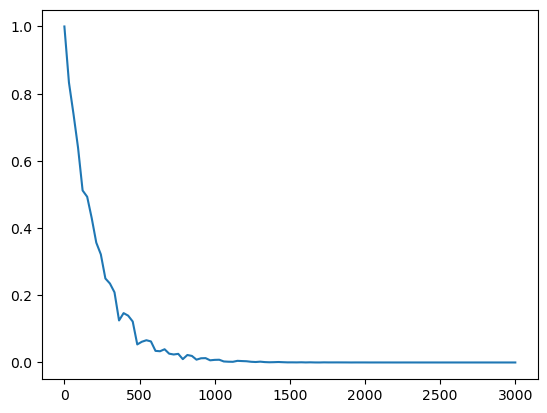

In [29]:
theta = np.random.randn(Zeppelin.theta_dim)
zep = Zeppelin.from_theta(theta)


signal = zep.signal(acq)

plt.plot(bvals, signal)

In [64]:
def stick_mu_samples(thetas):
    stick = Zeppelin.from_theta(thetas)
    mu = stick.mu
    # Convert to cartesian
    mu = jnp.array([jnp.sin(mu[0]) * jnp.cos(mu[1]), jnp.sin(mu[0]) * jnp.sin(mu[1]), jnp.cos(mu[0])])
    return mu

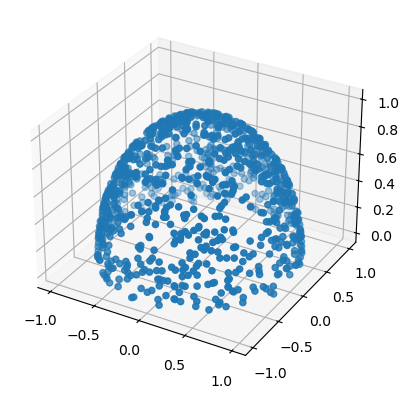

: 

In [66]:
pos = jax.vmap(stick_mu_samples)(np.random.randn(1000, Zeppelin.theta_dim))
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2])

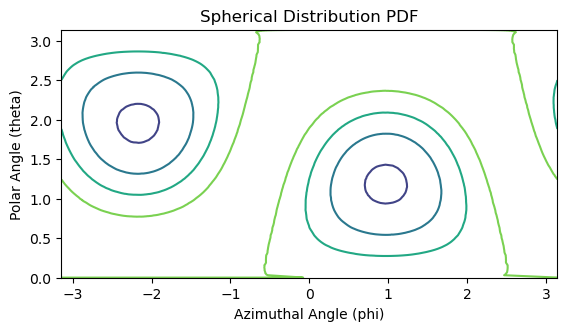

In [49]:
%matplotlib inline
theta = np.random.randn(Zeppelin.theta_dim)
zep = Zeppelin.from_theta(theta)
zep.to_fod().viz()

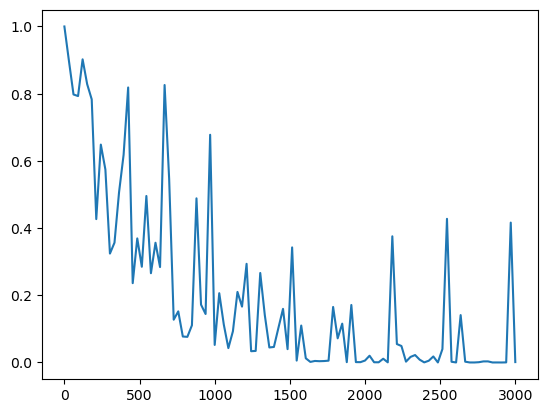

In [12]:
theta = np.random.randn(Dti.theta_dim)
dti = Dti.from_theta(theta)


signal = dti.signal(acq)

plt.plot(bvals, signal)

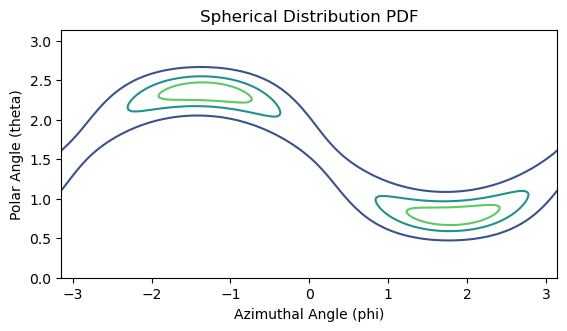

In [13]:
%matplotlib inline
dti.to_fod().viz()

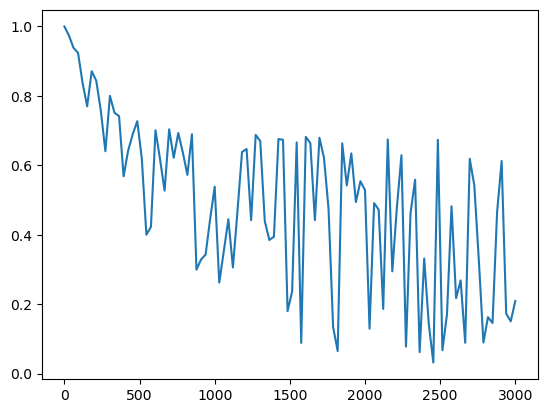

In [14]:
ball_stick = BallStick.from_theta(np.random.randn(BallStick.theta_dim))

signal = ball_stick.signal(acq, None)

plt.plot(bvals, signal)

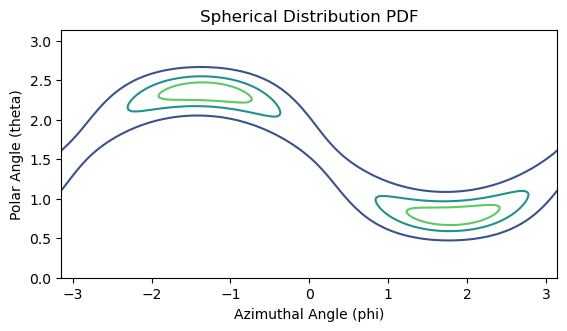

In [15]:
%matplotlib inline
dti.to_fod().viz()

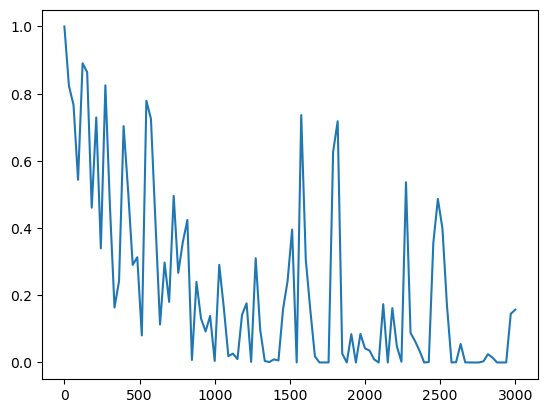

In [16]:
ball_stick = Ball2Stick.from_theta(np.random.randn(Ball2Stick.theta_dim))

signal = ball_stick.signal(acq, None)

plt.plot(bvals, signal)

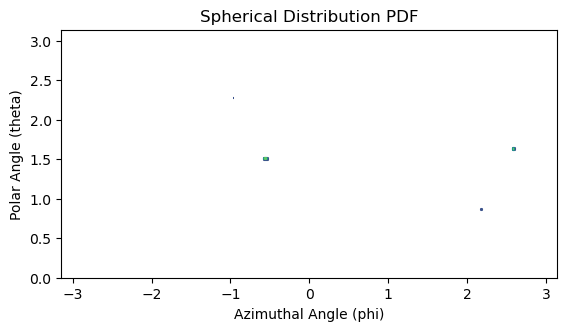

In [17]:
%matplotlib inline
ball_stick.to_fod().viz()

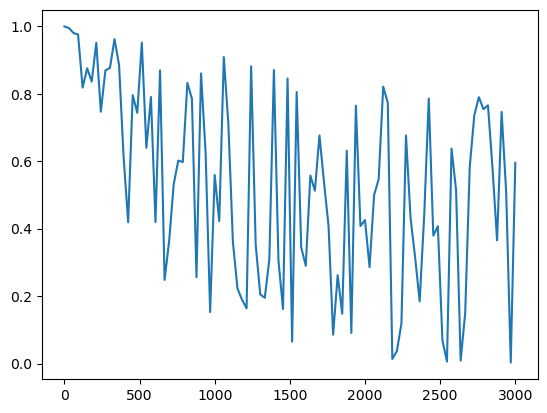

In [18]:
racket = WatsonStick.from_theta(np.random.randn(WatsonStick.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

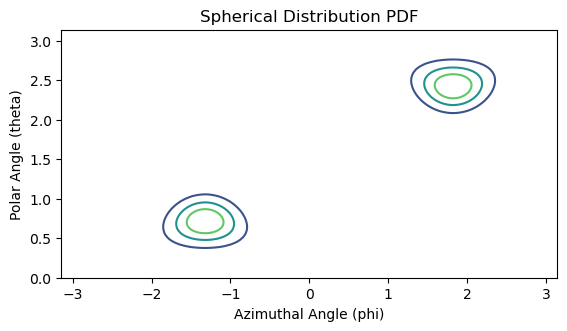

In [19]:
%matplotlib inline
racket.to_fod().viz()

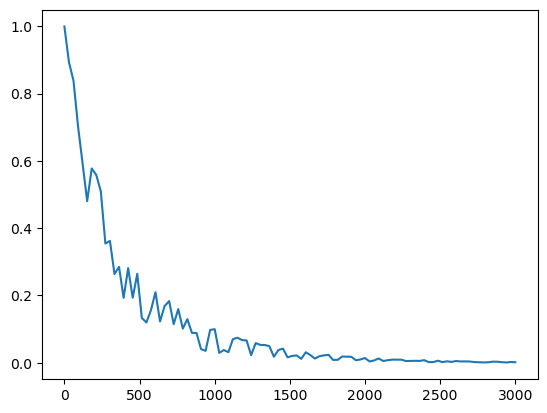

In [20]:
racket2 = WatsonZeppelin.from_theta(np.random.randn(WatsonZeppelin.theta_dim))
signal = racket2.signal(acq)
plt.plot(bvals, signal)

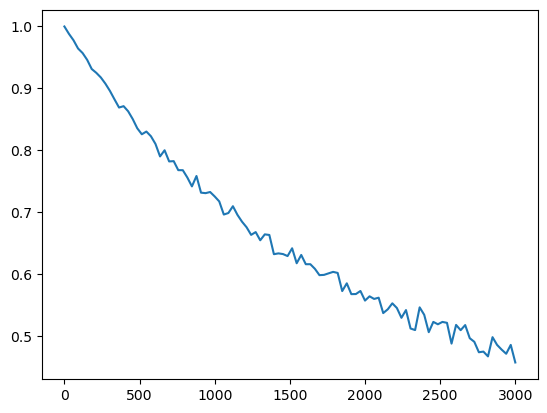

In [21]:
bracket = BinghamStick.from_theta(np.random.randn(BinghamStick.theta_dim))
signal = bracket.signal(acq)
plt.plot(bvals, signal)

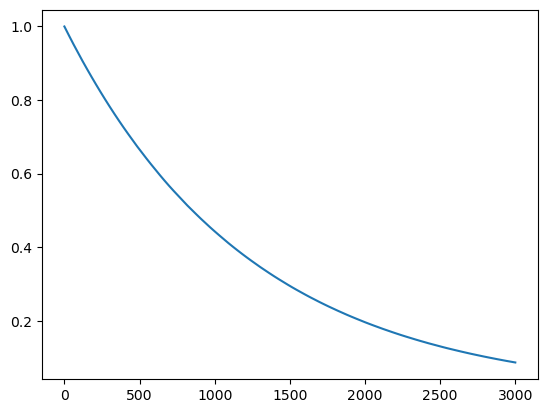

In [22]:
racket = BinghamZeppelin.from_theta(np.random.randn(BinghamStick.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

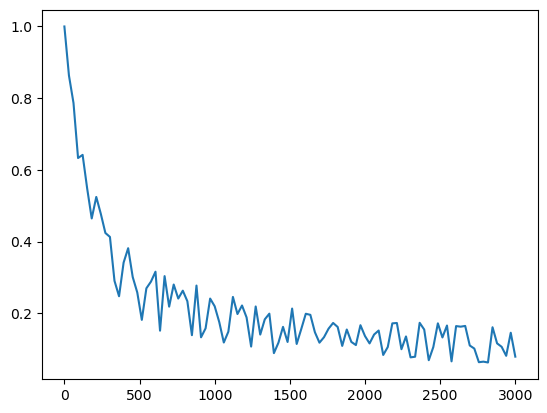

In [23]:
racket = NoddiW.from_theta(np.random.randn(NoddiW.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

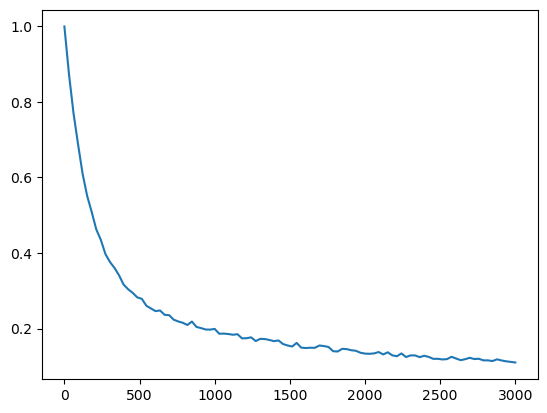

In [24]:
racket = NoddiB.from_theta(np.random.randn(NoddiB.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

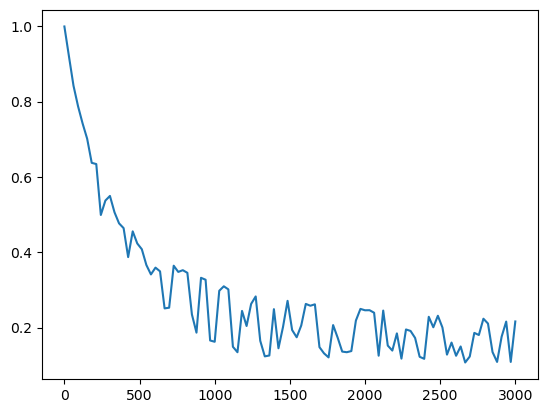

In [25]:
racket = SandiW.from_theta(np.random.randn(SandiW.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

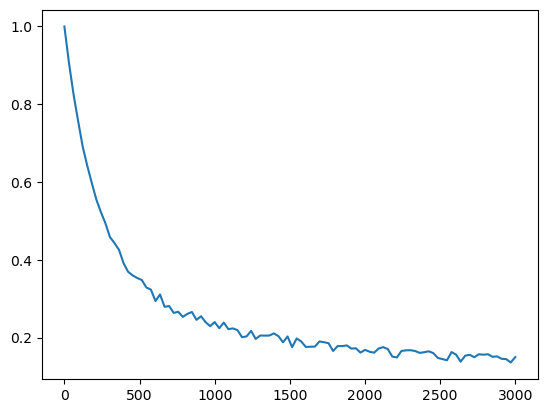

In [26]:
racket = SandiB.from_theta(np.random.randn(SandiB.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)